In [1]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../../'))

import EXP_neuro_fuzzy_toolbox as nft

In [2]:
import numpy as np

In [3]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

## Data

In [4]:
def z(x, y):
  return ((3) * ((1-x)**2) * (np.exp(-(x**2)-((y+1)**2))) - (10) * ((x/5)-(x**3)-(y**5)) * (np.exp(-(x**2)-(y**2))) - (1/3)*np.exp(-(x+1)**2-(y**2)))

#Training
x0 = np.random.uniform(-3,3,1000)
x1 = np.random.uniform(-3,3,1000)

e = np.random.normal(0,0.7,1000) #noise
Y = z(x0,x1) + e

#Testing
x0_test = np.random.uniform(-3,3,1000)
x1_test = np.random.uniform(-3,3,1000)

Y_test = z(x0_test,x1_test)

In [5]:
Y.mean(), Y.std()

(np.float64(0.41456709390814195), np.float64(2.0968061911274516))

In [6]:
Y_test.mean(), Y_test.std()

(np.float64(0.37348387208393613), np.float64(1.9927271030404359))

In [7]:
#Training
scaler = MinMaxScaler(feature_range=(-1, 1))
vstack_train = np.vstack((x0,x1)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x0_test,x1_test)).T
scaled_test = scaler.transform(vstack_test)

In [8]:
train_loader = data.DataLoader(
    data.TensorDataset(
        torch.tensor(scaled_train, dtype=torch.float32), 
        torch.tensor(Y, dtype=torch.float32)
        ), 
    batch_size = 8, 
    shuffle = True)

In [9]:
x_train = train_loader.dataset.tensors[0]
y_train = train_loader.dataset.tensors[1]

x_test = torch.tensor(scaled_test, dtype=torch.float32)
y_test = torch.tensor(Y_test, dtype=torch.float32)

## Model & Training

In [36]:
model = nft.ANFIS(
    mf_distribution=[5,4],
    outputs = 1,
    membership_function=nft.Gaussian_MF,
    dtype = x_train.dtype
)

In [37]:
#model.init_premises(x_train)

In [38]:
model.get_premises_structure()

x0                  x1          
         mu     sigma        mu     sigma
0 -0.792171  0.844078  0.130909  0.347762
1  0.534922  0.547158  0.482196  0.491013
2 -0.253171  0.529712 -0.077719  0.485171
3  0.342913  0.177741  0.398484  1.019725
4  0.457250  0.578562       NaN       NaN

In [39]:
model.get_premises()

[tensor([[-0.7922,  0.8441],
         [ 0.5349,  0.5472],
         [-0.2532,  0.5297],
         [ 0.3429,  0.1777],
         [ 0.4573,  0.5786]]),
 tensor([[ 0.1309,  0.3478],
         [ 0.4822,  0.4910],
         [-0.0777,  0.4852],
         [ 0.3985,  1.0197]])]

In [40]:
loss_fn = nn.functional.mse_loss
optimizer = torch.optim.AdamW
params = {'lr': 0.0001, 'weight_decay': 0.001}
early_stopping = nft.EarlyStopping(patience=30)

trainer = nft.Hybrid_learning_algorithm(
    epochs=500,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    validation=0.3,
    early_stopping=early_stopping
)

In [41]:
trainer(model, train_loader, verbose=True)

Epoch:   1/500 - loss: 0.961418 - validation loss: 1.152627
Epoch:   2/500 - loss: 0.967126 - validation loss: 1.153747
Epoch:   3/500 - loss: 0.962576 - validation loss: 1.184112
Epoch:   4/500 - loss: 1.032445 - validation loss: 1.212453
Epoch:   5/500 - loss: 0.975142 - validation loss: 1.173287
Epoch:   6/500 - loss: 1.008382 - validation loss: 1.172293
Epoch:   7/500 - loss: 0.958380 - validation loss: 1.151277
Epoch:   8/500 - loss: 0.966776 - validation loss: 1.186149
Epoch:   9/500 - loss: 0.962308 - validation loss: 1.150381
Epoch:  10/500 - loss: 0.983502 - validation loss: 1.183474
Epoch:  11/500 - loss: 0.939936 - validation loss: 1.125323
Epoch:  12/500 - loss: 0.945910 - validation loss: 1.125430
Epoch:  13/500 - loss: 0.950981 - validation loss: 1.127339
Epoch:  14/500 - loss: 0.943056 - validation loss: 1.119837
Epoch:  15/500 - loss: 0.932897 - validation loss: 1.128775
Epoch:  16/500 - loss: 0.939750 - validation loss: 1.123533
Epoch:  17/500 - loss: 0.992593 - valida

In [42]:
model.get_premises_structure()

x0                  x1          
         mu     sigma        mu     sigma
0 -0.792824  0.835002  0.131355  0.340915
1  0.528140  0.549688  0.478575  0.490673
2 -0.252925  0.523465 -0.069870  0.484188
3  0.036209  0.176864  0.383757  1.036176
4  0.461430  0.573202       NaN       NaN

In [43]:
test_measures = nft.get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.4454466998577118
RMSE: 0.6674179434776306
MAE: 0.4850783050060272
R2: 0.8878239393234253
MAPE: 635.7213745117188


In [44]:
train_measures = nft.get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.8637197017669678
RMSE: 0.9293652176856995
MAE: 0.7232844829559326
R2: 0.8035480976104736
MAPE: 2.335860013961792


In [45]:
model.get_rules_structure()

premises                               output 1 consequents  \
               x0                  x1                             x0   
               mu     sigma        mu     sigma                   c0   
rule 1  -0.792824  0.835002  0.131355  0.340915           298.668610   
rule 2  -0.792824  0.835002  0.478575  0.490673           317.091614   
rule 3  -0.792824  0.835002 -0.069870  0.484188            -2.878510   
rule 4  -0.792824  0.835002  0.383757  1.036176          -182.951904   
rule 5   0.528140  0.549688  0.131355  0.340915          -355.552246   
rule 6   0.528140  0.549688  0.478575  0.490673           133.359436   
rule 7   0.528140  0.549688 -0.069870  0.484188          -326.494812   
rule 8   0.528140  0.549688  0.383757  1.036176          -479.725159   
rule 9  -0.252925  0.523465  0.131355  0.340915            28.839329   
rule 10 -0.252925  0.523465  0.478575  0.490673           258.522583   
rule 11 -0.252925  0.523465 -0.069870  0.484188            -5.436798   
rule 12 -0.252925  0.523465  0.383757  1.036176          -134.655457   
rule 13  0.036209  0.176864  0.131355  0.340915            25.564682   
rule 14  0.036209  0.176864  0.478575  0.490673           -98.544334   
rule 15  0.036209  0.176864 -0.069870  0.484188          -270.925201   
rule 16  0.036209  0.176864  0.383757  1.036176           142.831390   
rule 17  0.461430  0.573202  0.131355  0.340915           239.068237   
rule 18  0.461430  0.573202  0.478575  0.490673            12.603882   
rule 19  0.461430  0.573202 -0.069870  0.484188           572.132935   
rule 20  0.461430  0.573202  0.383757  1.036176           517.204285   

                                   
                  x1               
                  c1           c2  
rule 1    510.455566   697.305420  
rule 2   2035.087402 -1187.778687  
rule 3    685.897705  1015.719727  
rule 4   -228.664124  -522.710754  
rule 5    634.266174   -94.126648  
rule 6    722.474731  -450.355103  
rule 7    440.695068  -296.870605  
rule 8   -135.658401  -398.191956  
rule 9   -704.926636  -879.577515  
rule 10 -3200.420898  2370.027832  
rule 11  -795.794434 -1421.067383  
rule 12   355.918701   553.122803  
rule 13 -1985.483032  -491.026550  
rule 14 -7679.270508  6569.377930  
rule 15 -3444.934570 -4449.497070  
rule 16   856.607239   847.682434  
rule 17  -626.762573   281.323212  
rule 18  -317.479736   -45.129364  
rule 19  -508.167175   237.276703  
rule 20    84.381378   390.134338

In [46]:
model.get_consequents_structure()[0]

,x0,x1,
,c0,c1,c2
rule 1,298.668610,510.455566,697.305420
rule 2,317.091614,2035.087402,-1187.778687
rule 3,-2.878510,685.897705,1015.719727
rule 4,-182.951904,-228.664124,-522.710754
rule 5,-355.552246,634.266174,-94.126648
rule 6,133.359436,722.474731,-450.355103
rule 7,-326.494812,440.695068,-296.870605
rule 8,-479.725159,-135.658401,-398.191956
rule 9,28.839329,-704.926636,-879.577515


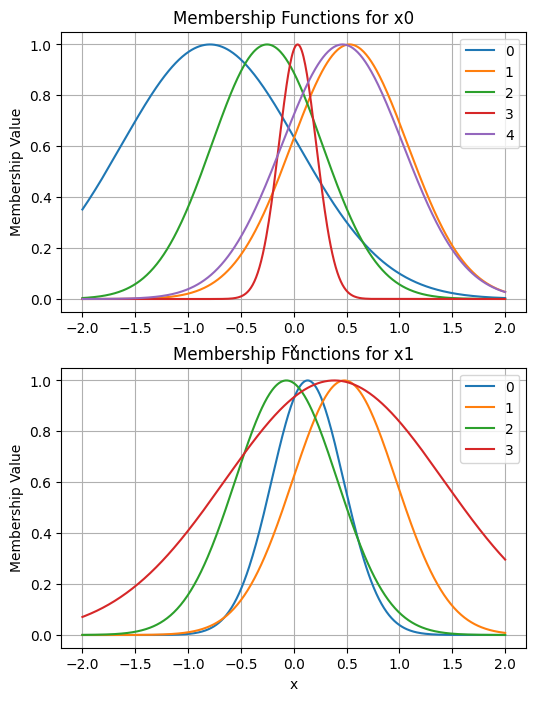

In [47]:
model.plot_premises(group_by_dim=True)